In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
from typing import Dict, Any
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, hamming_loss, classification_report, confusion_matrix
from sklearn.tree import export_text
import matplotlib
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
experiment1 = pd.read_csv('C:\\Users\\Szymon\\Desktop\\Thesis_use_this\\case-studies-final-project\\experiment_1_data\\experiment_1_rolling_phase_full_data.csv')
experiment2 = pd.read_csv('C:\\Users\\Szymon\\Desktop\\Thesis_use_this\\case-studies-final-project\\experiment_2_data\\experiment_2_scoring_phase_full_data.csv')

In [3]:
experiment1

,game_id,step_idx,dice_1,dice_2,dice_3,dice_4,dice_5,rolls_used,hold_die_1,hold_die_2,...,score_sheet_3,score_sheet_4,score_sheet_5,score_sheet_6,score_sheet_7,score_sheet_8,score_sheet_9,score_sheet_10,score_sheet_11,score_sheet_12
0,0,0,2,3,3,6,6,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,4,6,6,6,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,0,3,1,3,5,6,6,0,1,1,...,0,0,18,0,0,0,0,0,0,0
3,0,4,2,2,5,6,6,1,1,1,...,0,0,18,0,0,0,0,0,0,0
4,0,6,2,2,3,4,6,0,0,1,...,0,0,18,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259995,9999,31,2,3,3,3,6,1,1,0,...,16,15,12,25,0,25,30,40,0,26
259996,9999,33,2,4,4,6,6,0,0,0,...,16,15,12,25,13,25,30,40,0,26
259997,9999,34,1,2,2,3,4,1,1,0,...,16,15,12,25,13,25,30,40,0,26
259998,9999,36,2,2,2,3,5,0,0,0,...,16,15,12,25,13,25,30,40,0,26


In [4]:
experiment2

,game_id,step_idx,turn_number,dice_1,dice_2,dice_3,dice_4,dice_5,rolls_used,score_category,...,score_sheet_3,score_sheet_4,score_sheet_5,score_sheet_6,score_sheet_7,score_sheet_8,score_sheet_9,score_sheet_10,score_sheet_11,score_sheet_12
0,0,2,1,1,5,6,6,6,2,5,...,0,0,0,0,0,0,0,0,0,0
1,0,5,2,1,3,3,6,6,2,2,...,0,0,18,0,0,0,0,0,0,0
2,0,8,3,2,2,3,4,6,2,1,...,0,0,18,0,0,0,0,0,0,0
3,0,11,4,1,2,3,4,5,2,10,...,0,0,18,0,0,0,0,0,0,0
4,0,14,5,3,4,4,4,4,2,3,...,0,0,18,0,0,0,0,40,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129995,9999,26,9,4,5,5,6,6,2,12,...,16,15,12,25,0,25,30,40,0,0
129996,9999,29,10,1,1,1,2,6,2,0,...,16,15,12,25,0,25,30,40,0,26
129997,9999,32,11,1,3,3,3,3,2,7,...,16,15,12,25,0,25,30,40,0,26
129998,9999,35,12,2,2,2,3,3,2,1,...,16,15,12,25,13,25,30,40,0,26


In [5]:
# DATA LOADING FOR ALL 2 EXPERIMENTS
# helper functions to load datasets from pkl separately
import os
def load_experiment_1_raw(pkl_path: str) -> list:
    """Load Experiment 1 (Rolling Phase) data from pkl file"""
    print(f"Loading Experiment 1 data from: {pkl_path}")
    with open(pkl_path, "rb") as f:
        samples = pickle.load(f)
    print(f"  ✓ Loaded {len(samples)} rolling phase samples")
    return samples

def load_experiment_2_raw(pkl_path: str) -> list:
    """Load Experiment 2 (Scoring Phase) data from pkl file"""
    print(f"Loading Experiment 2 data from: {pkl_path}")
    with open(pkl_path, "rb") as f:
        samples = pickle.load(f)
    print(f"  ✓ Loaded {len(samples)} scoring phase samples")
    return samples

# CONVERTING RAW DATA TO PANDAS DATAFRAMES

def convert_exp1_to_dataframe(raw_samples: list) -> pd.DataFrame:
    """Convert Experiment 1 raw samples to DataFrame"""
    print("\nConverting Experiment 1 to DataFrame...")
    data_list = []
    
    for sample in raw_samples:
        dice = np.array(sample["dice"], dtype=np.int32)
        row = {
            "game_id": int(sample.get("game_id", 0)),
            "step_idx": int(sample.get("step_idx", 0)), 
            #"turn_number": int(sample.get("turn_number", 0)), # for weighting experiment/test for full game - what supervisor suggested to me
            # Raw dice features
            "dice_1": int(dice[0]),
            "dice_2": int(dice[1]),
            "dice_3": int(dice[2]),
            "dice_4": int(dice[3]),
            "dice_5": int(dice[4]),
            "rolls_used": int(sample.get("rolls_used", 0)),
            # Targets - one per die (what expert held)
            "hold_die_1": int(sample.get("hold_mask", [0]*5)[0]),
            "hold_die_2": int(sample.get("hold_mask", [0]*5)[1]),
            "hold_die_3": int(sample.get("hold_mask", [0]*5)[2]),
            "hold_die_4": int(sample.get("hold_mask", [0]*5)[3]),
            "hold_die_5": int(sample.get("hold_mask", [0]*5)[4]),
            "reward": float(sample.get("reward", 0)),
        }
        
        # Category availability
        available_categories = np.array(sample.get("available_categories", np.zeros(13)), dtype=np.int32)
        for i in range(13):
            row[f"cat_available_{i}"] = int(available_categories[i])
        
        # Score sheet at current step
        score_sheet = np.array(sample.get("score_sheet", np.zeros(13)), dtype=np.int32)
        for i in range(13):
            row[f"score_sheet_{i}"] = int(score_sheet[i])
        
        data_list.append(row)
    
    df = pd.DataFrame(data_list)
    print(f"  ✓ DataFrame shape: {df.shape}")
    return df

def convert_exp2_to_dataframe(raw_samples: list) -> pd.DataFrame:
    # Convert Experiment 2 raw samples to DataFrame
    print("\nConverting Experiment 2 to DataFrame...")
    data_list = []
    
    for sample in raw_samples:
        dice = np.array(sample["dice"], dtype=np.int32)
        row = {
            "game_id": int(sample.get("game_id", 0)),
            "step_idx": int(sample.get("step_idx", 0)),
            "turn_number": int(sample.get("turn_number", 0)),
            # Raw dice features
            "dice_1": int(dice[0]),
            "dice_2": int(dice[1]),
            "dice_3": int(dice[2]),
            "dice_4": int(dice[3]),
            "dice_5": int(dice[4]),
            "rolls_used": int(sample.get("rolls_used", 0)),          
            # Target - which category expert chose
            "score_category": int(sample.get("score_category", -1)),
            "score_category_name": sample.get("score_category_name", "Unknown"),
            "reward": float(sample.get("reward", 0)),
        }
        
        # Category availability
        available_categories = np.array(sample.get("available_categories", np.zeros(13)), dtype=np.int32)
        for i in range(13):
            row[f"cat_available_{i}"] = int(available_categories[i])
        
        # Score sheet
        score_sheet = np.array(sample.get("score_sheet", np.zeros(13)), dtype=np.int32)
        for i in range(13):
            row[f"score_sheet_{i}"] = int(score_sheet[i])
        
        data_list.append(row)
    
    df = pd.DataFrame(data_list)
    print(f"  ✓ DataFrame shape: {df.shape}")
    return df

# SAVE TO CSV

def save_experiment_to_csv(df: pd.DataFrame, experiment_name: str, output_dir: str = None) -> None:
    # Save experiment dataframe to CSV files with feature info and statistics 
    if output_dir is None:
        output_dir = f"{experiment_name}"
    
    Path(output_dir).mkdir(exist_ok=True)
    
    print(f"\n" + "="*70)
    print(f"SAVING {experiment_name} TO CSV: {output_dir}")
    print("="*70)
    
    # Full dataset
    csv_path = os.path.join(output_dir, f"{experiment_name}_full_data.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n✓ Full dataset: {csv_path}")
    print(f"  Shape: {df.shape}")
    print(f"  Size: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Feature information
    feature_info = pd.DataFrame({
        "Feature": df.columns,
        "Type": ["Integer" if df[col].dtype in [int, np.int32, np.int64] else "Float" for col in df.columns],
        "Null Count": [df[col].isnull().sum() for col in df.columns],
        "Unique Values": [df[col].nunique() for col in df.columns],
    })
    feature_info_path = os.path.join(output_dir, f"{experiment_name}_feature_info.csv")
    feature_info.to_csv(feature_info_path, index=False)
    print(f"\n✓ Feature information: {feature_info_path}")
    
    # Sample statistics
    stats = df.describe(include="all").T
    stats_path = os.path.join(output_dir, f"{experiment_name}_feature_statistics.csv")
    stats.to_csv(stats_path)
    print(f"\n✓ Feature statistics: {stats_path}")

# EXECUTION

print("="*70)
print("DATA LOADING FOR ALL EXPERIMENTS")
print("="*70)

# EXPERIMENT 1: ROLLING PHASE
print("\n# EXPERIMENT 1: ROLLING PHASE")
raw_exp1 = load_experiment_1_raw(
    "expert_data_pkl/experiment_1_rolling_phase/rolling_phase_dataset.pkl"
)
df_exp1 = convert_exp1_to_dataframe(raw_exp1)
#save_experiment_to_csv(df_exp1, "experiment_1_rolling_phase", output_dir="experiment_1_data")

# EXPERIMENT 2: SCORING PHASE
print("\n# EXPERIMENT 2: SCORING PHASE")
raw_exp2 = load_experiment_2_raw(
    "expert_data_pkl/experiment_2_scoring_phase/scoring_phase_dataset.pkl"
)
df_exp2 = convert_exp2_to_dataframe(raw_exp2)
#save_experiment_to_csv(df_exp2, "experiment_2_scoring_phase", output_dir="experiment_2_data")

print("\n" + "="*70)
print("✅ DATA GENERATION COMPLETE!")
print("="*70)
print("\nOutput files created:")
print("  📁 experiment_1_data/")
print("     ├── experiment_1_rolling_phase_full_data.csv")
print("     ├── experiment_1_rolling_phase_feature_info.csv")
print("     └── experiment_1_rolling_phase_feature_statistics.csv")
print("\n  📁 experiment_2_data/")
print("     ├── experiment_2_scoring_phase_full_data.csv")
print("     ├── experiment_2_scoring_phase_feature_info.csv")
print("     └── experiment_2_scoring_phase_feature_statistics.csv")

DATA LOADING FOR ALL EXPERIMENTS

# EXPERIMENT 1: ROLLING PHASE
Loading Experiment 1 data from: expert_data_pkl/experiment_1_rolling_phase/rolling_phase_dataset.pkl
  ✓ Loaded 260000 rolling phase samples

Converting Experiment 1 to DataFrame...
  ✓ DataFrame shape: (260000, 40)

# EXPERIMENT 2: SCORING PHASE
Loading Experiment 2 data from: expert_data_pkl/experiment_2_scoring_phase/scoring_phase_dataset.pkl
  ✓ Loaded 130000 scoring phase samples

Converting Experiment 2 to DataFrame...
  ✓ DataFrame shape: (130000, 38)

✅ DATA GENERATION COMPLETE!

Output files created:
  📁 experiment_1_data/
     ├── experiment_1_rolling_phase_full_data.csv
     ├── experiment_1_rolling_phase_feature_info.csv
     └── experiment_1_rolling_phase_feature_statistics.csv

  📁 experiment_2_data/
     ├── experiment_2_scoring_phase_full_data.csv
     ├── experiment_2_scoring_phase_feature_info.csv
     └── experiment_2_scoring_phase_feature_statistics.csv


In [6]:
# HELPER FUNCTIONS TO TRANSFORM DATA INTO CLASS LABELS AND BACK FOR DECISION TREES
def dice_decision_to_class(row):
    """Convert [hold_die_1, hold_die_2, hold_die_3, hold_die_4, hold_die_5] to class 0-31"""
    binary_str = ''.join([str(int(row[col])) for col in ["hold_die_1", "hold_die_2", "hold_die_3", "hold_die_4", "hold_die_5"]])
    return int(binary_str, 2)

def class_to_dice_decision(class_idx):
    """Convert class 0-31 back to a vector like [1 0 1 1 0]"""
    binary_str = format(class_idx, '05b')
    return [int(b) for b in binary_str]

In [7]:
# LOADING DATA FOR EXPERIMENT 1 
df_exp1 = pd.read_csv("experiment_1_data/experiment_1_rolling_phase_full_data.csv")
print(f"✓ Loaded Experiment 1 data with shape: {df_exp1.shape}")
print(f"  Columns: {list(df_exp1.columns)}")

✓ Loaded Experiment 1 data with shape: (260000, 40)
  Columns: ['game_id', 'step_idx', 'dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5', 'rolls_used', 'hold_die_1', 'hold_die_2', 'hold_die_3', 'hold_die_4', 'hold_die_5', 'reward', 'cat_available_0', 'cat_available_1', 'cat_available_2', 'cat_available_3', 'cat_available_4', 'cat_available_5', 'cat_available_6', 'cat_available_7', 'cat_available_8', 'cat_available_9', 'cat_available_10', 'cat_available_11', 'cat_available_12', 'score_sheet_0', 'score_sheet_1', 'score_sheet_2', 'score_sheet_3', 'score_sheet_4', 'score_sheet_5', 'score_sheet_6', 'score_sheet_7', 'score_sheet_8', 'score_sheet_9', 'score_sheet_10', 'score_sheet_11', 'score_sheet_12']


In [8]:
df_exp1_extended = df_exp1.copy()
df = df_exp1_extended

dice_cols = ['dice_1','dice_2','dice_3','dice_4','dice_5']

# GENERATING COUNT OF EACH FACE (1–6)
for face in range(1, 7):
    df[f'count_{face}'] = df[dice_cols].apply(lambda row: sum(row == face), axis=1)

# SUMMING UP ALL DICE FOR TOTAL VALUE
df['dice_sum'] = df[dice_cols].sum(axis=1)

def dice_counts(row):
    counts = row.value_counts()
    return pd.Series({i: counts.get(i, 0) for i in range(1,7)})

# GENERATING DICE PATTERN FEATURES
def hand_patterns(row):
    counts = row.value_counts().values
    features = {}
    features['has_pair'] = int(2 in counts)
    features['has_three'] = int(3 in counts)
    features['has_four'] = int(4 in counts)
    features['has_yahtzee'] = int(5 in counts)
    features['has_full_house'] = int(set(counts) == {2,3})
    features['has_two_pair'] = int(list(counts).count(2) == 2)
    return pd.Series(features)
pattern_features = df[dice_cols].apply(hand_patterns, axis=1)
df = pd.concat([df, pattern_features], axis=1)
df_exp1_extended = df.copy()

In [9]:
feature_rich = (
    ["dice_1", "dice_2", "dice_3", "dice_4", "dice_5", "rolls_used"] +
    [f"cat_available_{i}" for i in range(13)] +
    [f"score_sheet_{i}" for i in range(13)] +
    [f"count_{i}" for i in range(1, 7)] +
    ["dice_sum", "has_pair", "has_three", "has_four", "has_two_pair", "has_full_house", "has_yahtzee"]
)
target = df_exp1.apply(dice_decision_to_class, axis=1)
X_rich = df_exp1_extended[feature_rich].copy()
y_rich = target.copy()
print(f"\nFeatures (n={len(feature_rich)}): ")
print(f"  - Dice: dice_1 to dice_5")
print(f"  - Game state: rolls_used, cat_available_0-12, score_sheet_0-12")
print(f"  Total: {len(feature_rich)} features")
print(f"\nX shape: {X_rich.shape}")
print(f"y shape: {y_rich.shape}")
X_train_rich, X_test_rich, y_train_rich, y_test_rich = train_test_split(
    X_rich, y_rich, test_size=0.2, random_state=42
)

print(f"\nTrain/Test split:")
print(f"  Train: {len(X_train_rich)} samples")
print(f"  Test: {len(X_test_rich)} samples")


Features (n=45): 
  - Dice: dice_1 to dice_5
  - Game state: rolls_used, cat_available_0-12, score_sheet_0-12
  Total: 45 features

X shape: (260000, 45)
y shape: (260000,)

Train/Test split:
  Train: 208000 samples
  Test: 52000 samples


In [10]:
X_rich

,dice_1,dice_2,dice_3,dice_4,dice_5,rolls_used,cat_available_0,cat_available_1,cat_available_2,cat_available_3,...,count_4,count_5,count_6,dice_sum,has_pair,has_three,has_four,has_two_pair,has_full_house,has_yahtzee
0,2,3,3,6,6,0,1,1,1,1,...,0,0,2,20,1,0,0,1,0,0
1,1,4,6,6,6,1,1,1,1,1,...,1,0,3,23,0,1,0,0,0,0
2,1,3,5,6,6,0,1,1,1,1,...,0,1,2,21,1,0,0,0,0,0
3,2,2,5,6,6,1,1,1,1,1,...,0,1,2,21,1,0,0,1,0,0
4,2,2,3,4,6,0,1,1,0,1,...,1,0,1,17,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259995,2,3,3,3,6,1,0,1,0,0,...,0,0,1,17,0,1,0,0,0,0
259996,2,4,4,6,6,0,0,1,0,0,...,2,0,2,22,1,0,0,1,0,0
259997,1,2,2,3,4,1,0,1,0,0,...,1,0,0,12,1,0,0,0,0,0
259998,2,2,2,3,5,0,0,0,0,0,...,0,1,0,14,0,1,0,0,0,0


In [11]:
y_rich

0         28
1         24
2         28
3         28
4          9
          ..
259995    17
259996     7
259997    19
259998     3
259999     1
Length: 260000, dtype: int64

In [12]:
# LOADING DATA FOR EXPERIMENT 2

df_exp2 = pd.read_csv("experiment_2_data/experiment_2_scoring_phase_full_data.csv")
print(f"✓ Loaded Experiment 2 data with shape: {df_exp2.shape}")
print(f"  Columns: {list(df_exp2.columns)}")

# Define scoring categories for reference
scoring_categories = [
    'Ones', 'Twos', 'Threes', 'Fours', 'Fives', 'Sixes',
    '3-of-a-Kind', '4-of-a-Kind', 'Full House', 
    'Small Straight', 'Large Straight', 'Yahtzee', 'Chance'
]
# PREPARE SIMPLE FEATURES FOR EXPERIMENT 2
feature_simple_exp2 = ["dice_1", "dice_2", "dice_3", "dice_4", "dice_5"]
target_exp2 = df_exp2['score_category_name'].copy()
X_simple_exp2 = df_exp2[feature_simple_exp2].copy()
y_simple_exp2 = target_exp2.copy()
print(f"Features (n={len(feature_simple_exp2)}): {feature_simple_exp2}")
print(f"Target: scored_category (0-12 representing 13 scoring categories)")
print(f"\nX shape: {X_simple_exp2.shape}")
print(f"y shape: {y_simple_exp2.shape}")
print(f"\nTarget distribution:")
print(y_simple_exp2.value_counts().sort_index())
# TRAIN-TEST SPLIT FOR SIMPLE FEATURES (EXP 2)
X_train_simple_exp2, X_test_simple_exp2, y_train_simple_exp2, y_test_simple_exp2 = train_test_split(
    X_simple_exp2, y_simple_exp2, test_size=0.2, random_state=42
)
print(f"Train/Test split:")
print(f"  Train: {len(X_train_simple_exp2)} samples")
print(f"  Test: {len(X_test_simple_exp2)} samples")

✓ Loaded Experiment 2 data with shape: (130000, 38)
  Columns: ['game_id', 'step_idx', 'turn_number', 'dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5', 'rolls_used', 'score_category', 'score_category_name', 'reward', 'cat_available_0', 'cat_available_1', 'cat_available_2', 'cat_available_3', 'cat_available_4', 'cat_available_5', 'cat_available_6', 'cat_available_7', 'cat_available_8', 'cat_available_9', 'cat_available_10', 'cat_available_11', 'cat_available_12', 'score_sheet_0', 'score_sheet_1', 'score_sheet_2', 'score_sheet_3', 'score_sheet_4', 'score_sheet_5', 'score_sheet_6', 'score_sheet_7', 'score_sheet_8', 'score_sheet_9', 'score_sheet_10', 'score_sheet_11', 'score_sheet_12']
Features (n=5): ['dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5']
Target: scored_category (0-12 representing 13 scoring categories)

X shape: (130000, 5)
y shape: (130000,)

Target distribution:
score_category_name
Chance             10000
Fives              10000
Four of a Kind     10000
Fours             

In [13]:
# CREATE RICH FEATURES FOR EXPERIMENT 2
df_exp2_extended = df_exp2.copy()
df = df_exp2_extended
dice_cols = ['dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5']
# 1. Count of each face (1–6)
for face in range(1, 7):
    df[f'count_{face}'] = df[dice_cols].apply(lambda row: sum(row == face), axis=1)
# 2. Dice sum
df['dice_sum'] = df[dice_cols].sum(axis=1)
# 3. Hand pattern features
def hand_patterns(row):
    counts = row.value_counts().values
    features = {}
    features['has_pair'] = int(2 in counts)
    features['has_three'] = int(3 in counts)
    features['has_four'] = int(4 in counts)
    features['has_yahtzee'] = int(5 in counts)
    features['has_full_house'] = int(set(counts) == {2, 3})
    features['has_two_pair'] = int(list(counts).count(2) == 2)
    return pd.Series(features)
pattern_features = df[dice_cols].apply(hand_patterns, axis=1)
df = pd.concat([df, pattern_features], axis=1)
df_exp2_extended = df.copy()
print("✓ Created rich features:")
print("  - Face counts: count_1 to count_6")
print("  - Dice sum: dice_sum")
print("  - Hand patterns: has_pair, has_three, has_four, has_yahtzee, has_full_house, has_two_pair")
# PREPARE RICH FEATURES FOR EXPERIMENT 2
feature_rich_exp2 = (
    ["dice_1", "dice_2", "dice_3", "dice_4", "dice_5", "rolls_used"] +
    [f"cat_available_{i}" for i in range(13)] +
    [f"score_sheet_{i}" for i in range(13)] +
    [f"count_{i}" for i in range(1, 7)] +
    ["dice_sum", "has_pair", "has_three", "has_four", "has_two_pair", "has_full_house", "has_yahtzee"]
)
target_exp2 = df_exp2['score_category_name'].copy()
X_rich_exp2 = df_exp2_extended[feature_rich_exp2].copy()
y_rich_exp2 = target_exp2.copy()
print(f"Features (n={len(feature_rich_exp2)}): ")
print(f"  - Dice: dice_1 to dice_5")
print(f"  - Game state: rolls_used, cat_available_0-12, score_sheet_0-12")
print(f"  - Hand patterns: count_1-6, dice_sum, has_pair, has_three, has_four, has_two_pair, has_full_house, has_yahtzee")
print(f"  Total: {len(feature_rich_exp2)} features")
print(f"\nX shape: {X_rich_exp2.shape}")
print(f"y shape: {y_rich_exp2.shape}")
# TRAIN-TEST SPLIT FOR RICH FEATURES (EXP 2)
X_train_rich_exp2, X_test_rich_exp2, y_train_rich_exp2, y_test_rich_exp2 = train_test_split(
    X_rich_exp2, y_rich_exp2, test_size=0.2, random_state=42
)
print(f"Train/Test split:")
print(f"  Train: {len(X_train_rich_exp2)} samples")
print(f"  Test: {len(X_test_rich_exp2)} samples")

✓ Created rich features:
  - Face counts: count_1 to count_6
  - Dice sum: dice_sum
  - Hand patterns: has_pair, has_three, has_four, has_yahtzee, has_full_house, has_two_pair
Features (n=45): 
  - Dice: dice_1 to dice_5
  - Game state: rolls_used, cat_available_0-12, score_sheet_0-12
  - Hand patterns: count_1-6, dice_sum, has_pair, has_three, has_four, has_two_pair, has_full_house, has_yahtzee
  Total: 45 features

X shape: (130000, 45)
y shape: (130000,)
Train/Test split:
  Train: 104000 samples
  Test: 26000 samples


In [14]:
X_rich_exp2

,dice_1,dice_2,dice_3,dice_4,dice_5,rolls_used,cat_available_0,cat_available_1,cat_available_2,cat_available_3,...,count_4,count_5,count_6,dice_sum,has_pair,has_three,has_four,has_two_pair,has_full_house,has_yahtzee
0,1,5,6,6,6,2,1,1,1,1,...,0,1,3,24,0,1,0,0,0,0
1,1,3,3,6,6,2,1,1,1,1,...,0,0,2,19,1,0,0,1,0,0
2,2,2,3,4,6,2,1,1,0,1,...,1,0,1,17,1,0,0,0,0,0
3,1,2,3,4,5,2,1,0,0,1,...,1,1,0,15,0,0,0,0,0,0
4,3,4,4,4,4,2,1,0,0,1,...,4,0,0,19,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129995,4,5,5,6,6,2,1,1,0,0,...,1,2,2,26,1,0,0,1,0,0
129996,1,1,1,2,6,2,1,1,0,0,...,0,0,1,11,0,1,0,0,0,0
129997,1,3,3,3,3,2,0,1,0,0,...,0,0,0,13,0,0,1,0,0,0
129998,2,2,2,3,3,2,0,1,0,0,...,0,0,0,12,1,1,0,0,1,0


In [15]:
y_rich_exp2

0                  Sixes
1                 Threes
2                   Twos
3         Large Straight
4                  Fours
               ...      
129995            Chance
129996              Ones
129997    Four of a Kind
129998              Twos
129999           Yahtzee
Name: score_category_name, Length: 130000, dtype: object

# Actual analysis

In [16]:
exp1 = pd.concat([X_rich,y_rich.rename("target")], axis=1)
exp2 = pd.concat([X_rich_exp2,y_rich_exp2.rename("target")], axis=1)

In [17]:
exp1

,dice_1,dice_2,dice_3,dice_4,dice_5,rolls_used,cat_available_0,cat_available_1,cat_available_2,cat_available_3,...,count_5,count_6,dice_sum,has_pair,has_three,has_four,has_two_pair,has_full_house,has_yahtzee,target
0,2,3,3,6,6,0,1,1,1,1,...,0,2,20,1,0,0,1,0,0,28
1,1,4,6,6,6,1,1,1,1,1,...,0,3,23,0,1,0,0,0,0,24
2,1,3,5,6,6,0,1,1,1,1,...,1,2,21,1,0,0,0,0,0,28
3,2,2,5,6,6,1,1,1,1,1,...,1,2,21,1,0,0,1,0,0,28
4,2,2,3,4,6,0,1,1,0,1,...,0,1,17,1,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259995,2,3,3,3,6,1,0,1,0,0,...,0,1,17,0,1,0,0,0,0,17
259996,2,4,4,6,6,0,0,1,0,0,...,0,2,22,1,0,0,1,0,0,7
259997,1,2,2,3,4,1,0,1,0,0,...,0,0,12,1,0,0,0,0,0,19
259998,2,2,2,3,5,0,0,0,0,0,...,1,0,14,0,1,0,0,0,0,3


In [18]:
print(exp1.shape, exp2.shape)

(260000, 46) (130000, 46)


In [19]:
print(exp1.head())
print(exp2.head())

   dice_1  dice_2  dice_3  dice_4  dice_5  rolls_used  cat_available_0  \
0       2       3       3       6       6           0                1   
1       1       4       6       6       6           1                1   
2       1       3       5       6       6           0                1   
3       2       2       5       6       6           1                1   
4       2       2       3       4       6           0                1   

   cat_available_1  cat_available_2  cat_available_3  ...  count_5  count_6  \
0                1                1                1  ...        0        2   
1                1                1                1  ...        0        3   
2                1                1                1  ...        1        2   
3                1                1                1  ...        1        2   
4                1                0                1  ...        0        1   

   dice_sum  has_pair  has_three  has_four  has_two_pair  has_full_house  \
0   

In [20]:
print(exp1.info())
print(exp2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260000 entries, 0 to 259999
Data columns (total 46 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   dice_1            260000 non-null  int64
 1   dice_2            260000 non-null  int64
 2   dice_3            260000 non-null  int64
 3   dice_4            260000 non-null  int64
 4   dice_5            260000 non-null  int64
 5   rolls_used        260000 non-null  int64
 6   cat_available_0   260000 non-null  int64
 7   cat_available_1   260000 non-null  int64
 8   cat_available_2   260000 non-null  int64
 9   cat_available_3   260000 non-null  int64
 10  cat_available_4   260000 non-null  int64
 11  cat_available_5   260000 non-null  int64
 12  cat_available_6   260000 non-null  int64
 13  cat_available_7   260000 non-null  int64
 14  cat_available_8   260000 non-null  int64
 15  cat_available_9   260000 non-null  int64
 16  cat_available_10  260000 non-null  int64
 17  cat_availa

In [21]:
exp1

,dice_1,dice_2,dice_3,dice_4,dice_5,rolls_used,cat_available_0,cat_available_1,cat_available_2,cat_available_3,...,count_5,count_6,dice_sum,has_pair,has_three,has_four,has_two_pair,has_full_house,has_yahtzee,target
0,2,3,3,6,6,0,1,1,1,1,...,0,2,20,1,0,0,1,0,0,28
1,1,4,6,6,6,1,1,1,1,1,...,0,3,23,0,1,0,0,0,0,24
2,1,3,5,6,6,0,1,1,1,1,...,1,2,21,1,0,0,0,0,0,28
3,2,2,5,6,6,1,1,1,1,1,...,1,2,21,1,0,0,1,0,0,28
4,2,2,3,4,6,0,1,1,0,1,...,0,1,17,1,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259995,2,3,3,3,6,1,0,1,0,0,...,0,1,17,0,1,0,0,0,0,17
259996,2,4,4,6,6,0,0,1,0,0,...,0,2,22,1,0,0,1,0,0,7
259997,1,2,2,3,4,1,0,1,0,0,...,0,0,12,1,0,0,0,0,0,19
259998,2,2,2,3,5,0,0,0,0,0,...,1,0,14,0,1,0,0,0,0,3


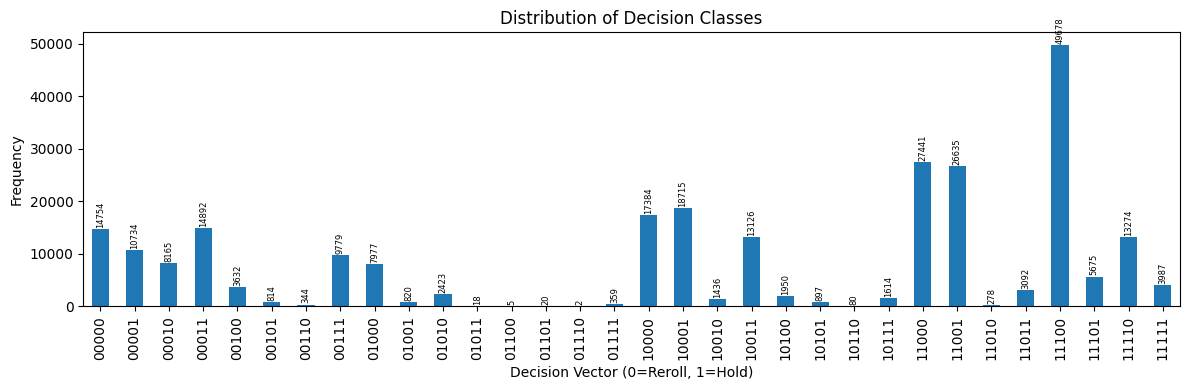

In [22]:
import matplotlib.pyplot as plt

counts = exp1['target'].value_counts().sort_index()

labels = [
    ''.join(map(str, class_to_dice_decision(i)))
    for i in counts.index
]

plt.figure(figsize=(12, 4))
for i, count in enumerate(counts):
    plt.text(i, count + 200, str(count),
             ha='center', va='bottom',
             rotation=90, fontsize=6)
counts.plot(kind="bar")
plt.title("Distribution of Decision Classes")
plt.xlabel("Decision Vector (0=Reroll, 1=Hold)")
plt.ylabel("Frequency")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.tight_layout()
plt.show()

In [23]:
counts = exp1['target'].value_counts().sort_index()
counts

target
0     14754
1     10734
2      8165
3     14892
4      3632
5       814
6       344
7      9779
8      7977
9       820
10     2423
11       18
12        5
13       20
14        2
15      359
16    17384
17    18715
18     1436
19    13126
20     1950
21      897
22       80
23     1614
24    27441
25    26635
26      278
27     3092
28    49678
29     5675
30    13274
31     3987
Name: count, dtype: int64

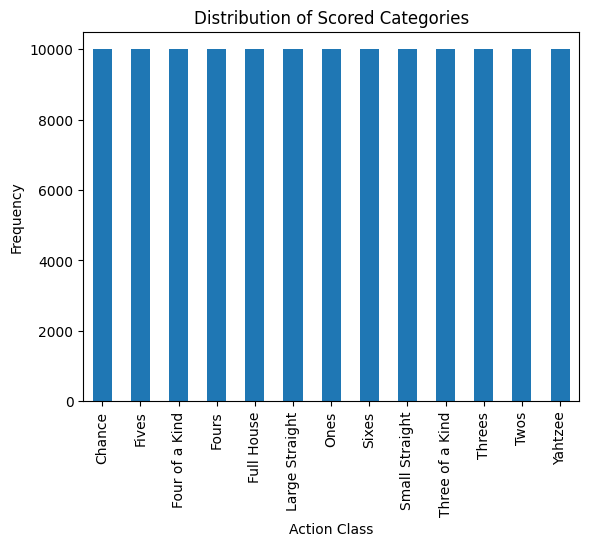

In [24]:
exp2['target'].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Scored Categories")
plt.xlabel("Action Class")
plt.ylabel("Frequency")
plt.show()

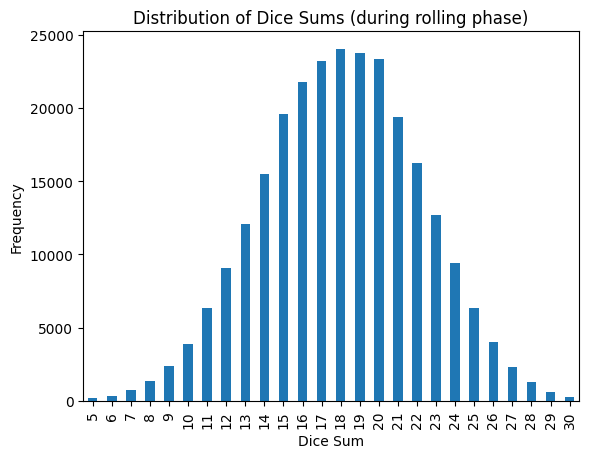

In [25]:
exp1['dice_sum'].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Dice Sums (during rolling phase)")
plt.xlabel("Dice Sum")
plt.ylabel("Frequency")
plt.show()

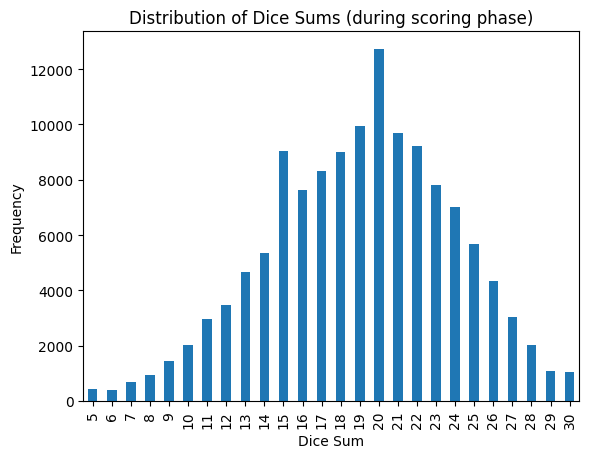

In [26]:
exp2['dice_sum'].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Dice Sums (during scoring phase)")
plt.xlabel("Dice Sum")
plt.ylabel("Frequency")
plt.show()

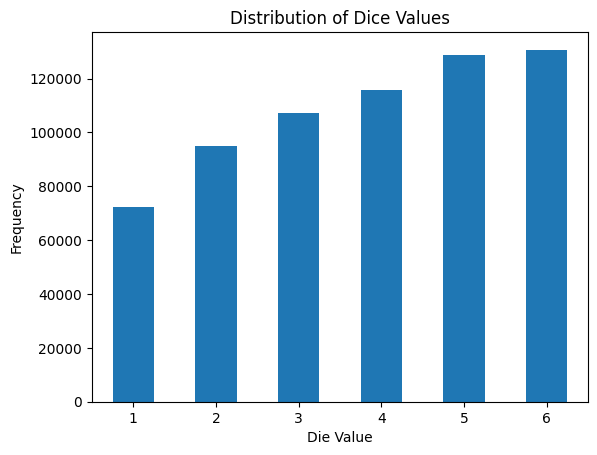

In [27]:
dice_cols = ['dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5']

all_dice = exp2[dice_cols].values.flatten()

pd.Series(all_dice).value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Dice Values")
plt.xlabel("Die Value")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

In [28]:
for col in ['dice_1','dice_2','dice_3','dice_4','dice_5']:
    print(exp1[col].mean())

1.7291076923076922
2.717380769230769
3.656873076923077
4.542115384615385
5.382023076923077


In [29]:
rolling_df = exp1.copy()
scoring_df = exp2.copy()
#scoring_df = pd.concat([scoring_df,scoring_df])
#scoring_df = pd.concat([scoring_df,scoring_df])
X = rolling_df.drop(columns=["target"])
y = rolling_df["target"]
# Learning Curve Function
def plot_learning_curve(
    df,
    title,
    max_depth=None,
    random_state=42
):

    X = df.drop(columns=["target"])
    y = df["target"]

    # fixed test set
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    train_sizes = np.unique(
        np.geomspace(
            1000,
            len(X_train),
            12,
            dtype=int
        )
    )

    accuracies = []

    for size in train_sizes:

        X_subset = X_train.iloc[:size]
        y_subset = y_train.iloc[:size]

        model = DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=random_state
        )

        model.fit(X_subset, y_subset)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        accuracies.append(acc)

        print(
            f"Samples: {size:>7} | "
            f"Accuracy: {acc:.4f}"
        )

    plt.figure(figsize=(8,5))

    plt.plot(
        train_sizes,
        accuracies,
        marker="o",
        linewidth=2
    )

    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.title(title)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "samples": train_sizes,
        "accuracy": accuracies
    })

Samples:    1000 | Accuracy: 0.6063
Samples:    1624 | Accuracy: 0.6707
Samples:    2639 | Accuracy: 0.7081
Samples:    4287 | Accuracy: 0.7398
Samples:    6965 | Accuracy: 0.7651
Samples:   11315 | Accuracy: 0.7826
Samples:   18382 | Accuracy: 0.8070
Samples:   29862 | Accuracy: 0.8289
Samples:   48513 | Accuracy: 0.8461
Samples:   78812 | Accuracy: 0.8644
Samples:  128035 | Accuracy: 0.8788
Samples:  208000 | Accuracy: 0.8932


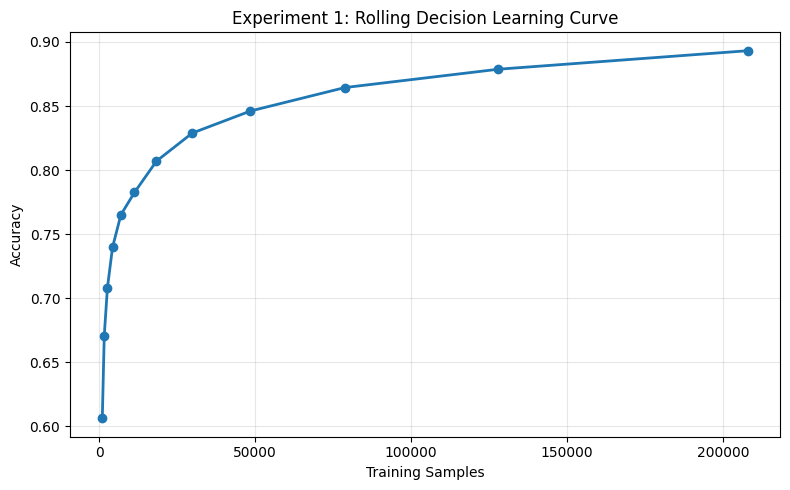

In [30]:
rolling_curve = plot_learning_curve(
    rolling_df,
    "Experiment 1: Rolling Decision Learning Curve",
    max_depth=20
)

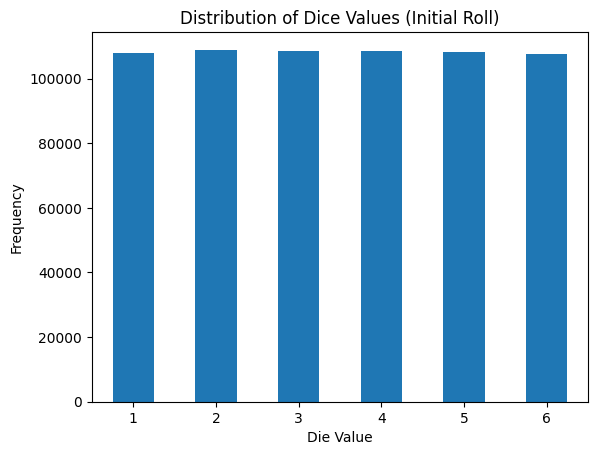

<Figure size 600x400 with 0 Axes>

In [ ]:
random_roll = exp1[exp1['rolls_used'] == 0]
random_roll
dice_cols = ['dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5']

all_dice = random_roll[dice_cols].values.flatten()

pd.Series(all_dice).value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Dice Values (Initial Roll)")
plt.xlabel("Die Value")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.figure(figsize=(6,4))
#plt.savefig("first_roll.png",  dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

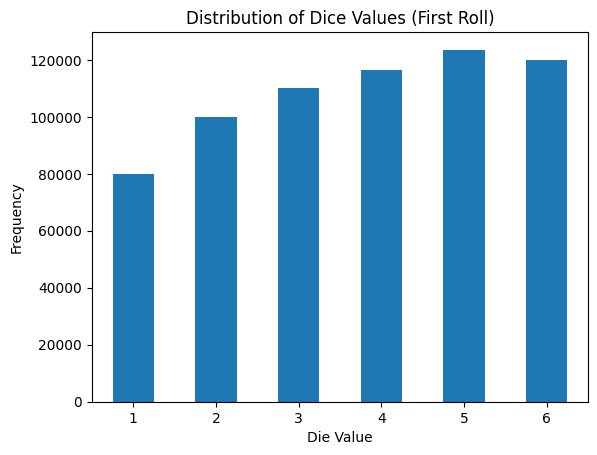

<Figure size 600x400 with 0 Axes>

In [38]:
first_roll = exp1[exp1['rolls_used'] == 1]
random_roll
dice_cols = ['dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5']

all_dice = first_roll[dice_cols].values.flatten()

pd.Series(all_dice).value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Dice Values (First Roll)")
plt.xlabel("Die Value")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.figure(figsize=(6,4))
#plt.savefig("last_roll.png", figsize=(6, 4), dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

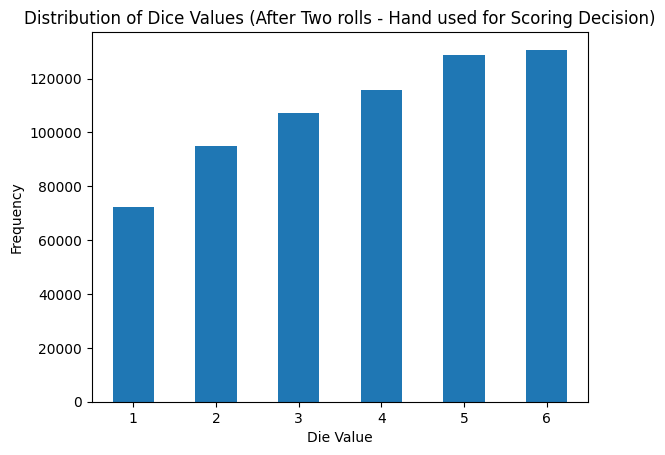

<Figure size 600x400 with 0 Axes>

In [42]:
second_roll = exp1[exp1['rolls_used'] == 2]
random_roll
dice_cols = ['dice_1', 'dice_2', 'dice_3', 'dice_4', 'dice_5']

all_dice = exp2[dice_cols].values.flatten()

pd.Series(all_dice).value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Dice Values (After Two rolls - Hand used for Scoring Decision)")
plt.xlabel("Die Value")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

plt.figure(figsize=(6,4))
plt.show()

Samples:    1000 | Accuracy: 0.7159
Samples:    1525 | Accuracy: 0.7686
Samples:    2326 | Accuracy: 0.8115
Samples:    3548 | Accuracy: 0.8436
Samples:    5413 | Accuracy: 0.8730
Samples:    8257 | Accuracy: 0.8927
Samples:   12595 | Accuracy: 0.9045
Samples:   19211 | Accuracy: 0.9228
Samples:   29304 | Accuracy: 0.9342
Samples:   44699 | Accuracy: 0.9466
Samples:   68181 | Accuracy: 0.9544
Samples:  104000 | Accuracy: 0.9615


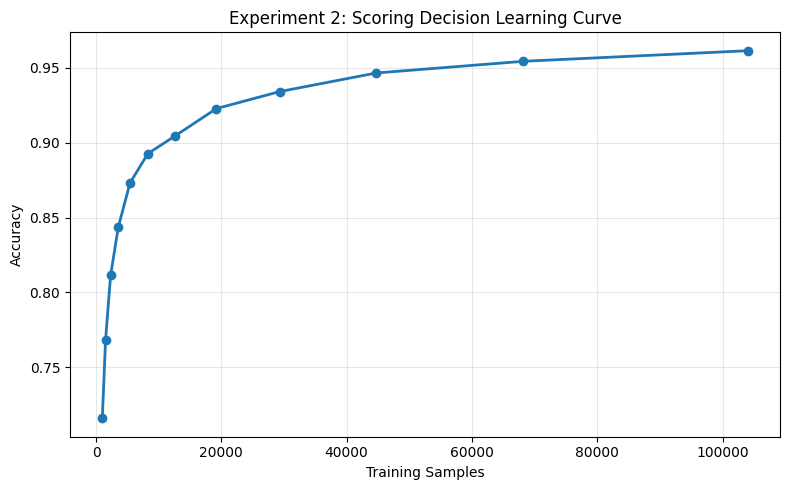

In [43]:
scoring_curve = plot_learning_curve(
    scoring_df,
    "Experiment 2: Scoring Decision Learning Curve",
    max_depth=20
)